The goal of this project is to estimate realistic values for the influence parameter $\delta$ in [Weston's UBI model](https://arxiv.org/abs/2601.07626).

# Deriving a Formula for $\delta$

We start by deriving a formula for $\delta$ in terms of the other parameters from Definition 3.1 in the paper:
$$
\begin{align*}
    \alpha_i w_{i,t} \left( \lambda_{keep} + \frac{\lambda_{ubi}}{I} (1 + \delta (I-1)) \right) &= \frac{u_i'(L_{i,t})}{u_i(L_{i,t})} \\
    \alpha_i w_{i,t} \left( \lambda_{keep} + \frac{\lambda_{ubi}}{I} (1 + \delta (I-1)) \right) &= \frac{\beta_i}{L_{i,t}} - \frac{\gamma_i}{1 - L_{i,t}} \\
    \delta 
    &= \frac{I}{I-1} \left( 
    \frac{1}{\alpha_i w_{i,t} \lambda_{ubi}} \left( \frac{\beta_i}{L_{i,t}} - \frac{\gamma_i}{1 - L_{i,t}} \right)
    - \frac{\lambda_{keep} + \frac{\lambda_{ubi}}{I}}{\lambda_{ubi}}
\right)
\end{align*}
$$
Because we will be looking at country-level economies where the agent population $I$ reaches into the millions, we can safely consider only the limit as $I \rightarrow \infty$.
For simplicity, we also assume that all agents in the model are identical and that their wage rates $w_{i,t}$ and labor proportions $L_{i,t}$ are constant for all time $t \in [0,T]$.
Thus, the final formula we will be working with is
$$
\begin{align*}
    \delta 
    &= \frac{1}{\alpha w \lambda_{ubi}} \left( \frac{\beta}{L} - \frac{\gamma}{1 - L} \right)
    - \frac{\lambda_{keep}}{\lambda_{ubi}}
\end{align*}
$$

# Estimates via Real-World Data

Each model parameter is estimated as follows:

- We use the [OECD *Average annual hours actually worked per worker* dataset](https://data-explorer.oecd.org/vis?fs[0]=Topic%2C0%7CEmployment%23JOB%23&pg=0&fc=Topic&bp=true&snb=68&df[ds]=dsDisseminateFinalDMZ&df[id]=DSD_HW%40DF_AVG_ANN_HRS_WKD&df[ag]=OECD.ELS.SAE&df[vs]=1.0&dq=AUS%2BAUT%2BBEL%2BCAN%2BCHL%2BCOL%2BCRI%2BCZE%2BDNK%2BEST%2BFIN%2BFRA%2BDEU%2BGRC%2BHUN%2BISL%2BIRL%2BISR%2BITA%2BJPN%2BKOR%2BLVA%2BLTU%2BLUX%2BMEX%2BNLD%2BNZL%2BNOR%2BPOL%2BPRT%2BSVK%2BSVN%2BESP%2BSWE%2BCHE%2BTUR%2BGBR%2BUSA%2BOECD............&pd=%2C&to[TIME_PERIOD]=false&vw=tb) to estimate the labor proportion $L$.
    - $L$ is the proportion of time that agents spend working, so this can be estimated as $$L = \frac{\text{annual hours of labor}}{\text{annual waking hours}}$$

<!-- - Previous research has found that people typically have a constant relative risk aversion of around 2 (see [Christensen et. al.](https://www.sciencedirect.com/science/article/pii/S0022053112000087)).  -->
- Weston's model assumes a constant absolute risk aversion of $\alpha$, so we have $$\alpha = ARA = \frac{RRA}{c}$$ where $c$ is individual consumption
    - The process of estimating the absolute risk aversion is explained in `risk_aversion.ipynb`
    - We use the [OECD *Annual GDP and consumption per capita* dataset](https://data-explorer.oecd.org/vis?tm=per%20capita&pg=0&snb=78&df[ds]=dsDisseminateFinalDMZ&df[id]=DSD_NAMAIN10%40DF_TABLE1_EXPENDITURE_HCPC&df[ag]=OECD.SDD.NAD&df[vs]=2.0&dq=A.AUS%2BAUT%2BBEL%2BCAN%2BCHL%2BCOL%2BCRI%2BCZE%2BDNK%2BEST%2BFIN%2BFRA%2BDEU%2BGRC%2BHUN%2BISL%2BIRL%2BISR%2BITA%2BJPN%2BKOR%2BLVA%2BLTU%2BLUX%2BMEX%2BNLD%2BNZL%2BNOR%2BPOL%2BPRT%2BSVK%2BSVN%2BESP%2BSWE%2BCHE%2BTUR%2BGBR%2BUSA...P41_POP.......&pd=%2C&to[TIME_PERIOD]=false&vw=tb) to estimate the consumption $c$.

- Because UBI is essentially a welfare policy, we use a country's current labor/welfare policy as a proxy in order to estimate $w$, $\lambda_{keep}$, and $\lambda_{ubi}$
    - All metrics in this section are taken from the [OECD *Labour taxation* dataset](https://data-explorer.oecd.org/vis?fs[0]=Topic%2C1%7CTaxation%23TAX%23%7CPersonal%20and%20property%20tax%23TAX_PPT%23&pg=0&fc=Topic&bp=true&snb=13&df[ds]=dsDisseminateFinalDMZ&df[id]=DSD_TAX_WAGES_COMP%40DF_TW_COMP&df[ag]=OECD.CTP.TPS&df[vs]=2.1&dq=.MR_TW_PE%2BNIAT%2BGLCBT..S_C0.AW100._Z.A&to[TIME_PERIOD]=false&pd=%2C&vw=tb).
    - $w$ is the wage that workers earn if they spend all of their time working, so we have $$w = \frac{\text{annual earnings}}{L}$$
    In the model, the government directly takes a share $1 - \lambda_{keep}$ of the worker's wages $w$. 
    However, in the real world both the employee and employer pay social security taxes, so we have
    $$\text{annual earnings} = \text{net pay} + \text{employee taxes} + \text{employer taxes} = \text{gross labor costs}$$
    - We also suggest that $\lambda_{keep}$ and $\lambda_{ubi}$ should satisfy the equation $$\lambda_{keep} + \lambda_{ubi} = 1 - \text{tax wedge}$$

We simply guess the values of $\beta, \gamma, \lambda_{keep}$ and $\lambda_{ubi}$.

In [111]:
%pip install matplotlib ipympl -r requirements.txt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [112]:
%matplotlib widget
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, MaxNLocator
import plotly.graph_objects as go
from ipywidgets import interact, FloatSlider, Layout

In [113]:
def data_df(start_year=None, end_year=None):
    """
    Load and consolidate OECD data from four CSV files.
    
    Parameters
    ----------
    start_year : int, optional
        Starting year (inclusive). If None, uses earliest available year.
    end_year : int, optional
        Ending year (inclusive). If None, uses latest available year.
    
    Returns
    -------
    pd.DataFrame
        MultiIndex DataFrame with (Reference area, Measure) as index,
        TIME_PERIOD as columns, and OBS_VALUE as values.
    """
    
    # Labour taxation data
    labour_df = pd.read_csv("OECD_labour_taxation.csv")

    target_measures = [
        "Marginal tax wedge of the principal earner",
        "Gross labour costs before taxes",
    ]
    labour_clean = labour_df[labour_df["Measure"].isin(target_measures)][
        ["Reference area", "Measure", "TIME_PERIOD", "OBS_VALUE"]
    ].copy()
    labour_clean["OBS_VALUE"] = pd.to_numeric(labour_clean["OBS_VALUE"], errors="coerce")
    
    # Hours worked data
    hours_df = pd.read_csv("OECD_avg_annual_hours_worked_per_worker.csv")
    hours_clean = hours_df[["Reference area", "TIME_PERIOD", "OBS_VALUE"]].copy()
    hours_clean["Measure"] = "Hours worked"
    hours_clean["OBS_VALUE"] = pd.to_numeric(hours_clean["OBS_VALUE"], errors="coerce")
    hours_clean = hours_clean[["Reference area", "Measure", "TIME_PERIOD", "OBS_VALUE"]]
    
    # Consumption data
    cons_df = pd.read_csv("OECD_consumption_per_capita.csv")
    cons_clean = cons_df[["Reference area", "TIME_PERIOD", "OBS_VALUE"]].copy()
    cons_clean["Measure"] = "Consumption per capita"
    cons_clean["OBS_VALUE"] = pd.to_numeric(cons_clean["OBS_VALUE"], errors="coerce")
    cons_clean = cons_clean[["Reference area", "Measure", "TIME_PERIOD", "OBS_VALUE"]]

    # Risk aversion data
    ra_df = pd.read_csv("estimated_risk_aversion.csv")
    ra_clean = ra_df.rename(columns={ra_df.columns[0]: "Reference area", "Year": "TIME_PERIOD"}).copy()
    ra_clean["TIME_PERIOD"] = pd.to_numeric(ra_clean["TIME_PERIOD"], errors="coerce")
    ra_measures = ra_clean.melt(
        id_vars=["Reference area", "TIME_PERIOD"],
        value_vars=["optimal_h", "rra", "ara"],
        var_name="Measure",
        value_name="OBS_VALUE",
    )
    ra_measures["Measure"] = ra_measures["Measure"].replace({
        "optimal_h": "Optimal h",
        "rra": "Relative risk aversion",
        "ara": "Absolute risk aversion",
    })
    ra_measures["OBS_VALUE"] = pd.to_numeric(ra_measures["OBS_VALUE"], errors="coerce")
    ra_measures = ra_measures[["Reference area", "Measure", "TIME_PERIOD", "OBS_VALUE"]]
    
    # Consolidate into one dataframe
    consolidated = pd.concat([labour_clean, hours_clean, cons_clean, ra_measures], ignore_index=True)
    
    consolidated["TIME_PERIOD"] = pd.to_numeric(
        consolidated["TIME_PERIOD"], errors="coerce"
    )
    
    # Create multi-index dataframe: (Reference area, Measure) x TIME_PERIOD
    result = consolidated.pivot_table(
        index=["Reference area", "Measure"],
        columns="TIME_PERIOD",
        values="OBS_VALUE",
        aggfunc="first",
    ).sort_index()
    
    # Filter by year
    if start_year is None:
        start_year = int(result.columns.min())
    if end_year is None:
        end_year = int(result.columns.max())
    
    years_in_range = [col for col in result.columns if start_year <= col <= end_year]
    result = result[years_in_range]
    
    return result

In [114]:
df = data_df(start_year=2013, end_year=2024)
us_swe_df = df.loc[(['United States', 'Sweden'], slice(None)), :]
us_swe_df

TIME_PERIOD                                                        2013  \
Reference area Measure                                                    
United States  Absolute risk aversion                          0.000049   
               Consumption per capita                      39232.924966   
               Gross labour costs before taxes             53041.211000   
               Hours worked                                 1825.439000   
               Marginal tax wedge of the principal earner     43.613562   
               Optimal h                                       1.980000   
               Relative risk aversion                          2.417827   
Sweden         Absolute risk aversion                          0.000024   
               Consumption per capita                      28927.452492   
               Gross labour costs before taxes             60869.905439   
               Hours worked                                 1464.517000   
               Marginal tax wedge of the principal earner     48.052047   
               Optimal h                                       0.750000   
               Relative risk aversion                          1.644693   

TIME_PERIOD                                                        2014  \
Reference area Measure                                                    
United States  Absolute risk aversion                          0.000047   
               Consumption per capita                      40538.572628   
               Gross labour costs before taxes             54526.419675   
               Hours worked                                 1830.360000   
               Marginal tax wedge of the principal earner     43.613562   
               Optimal h                                       1.980000   
               Relative risk aversion                          2.372819   
Sweden         Absolute risk aversion                          0.000025   
               Consumption per capita                      29491.031783   
               Gross labour costs before taxes             61468.083641   
               Hours worked                                 1465.423000   
               Marginal tax wedge of the principal earner     48.150966   
               Optimal h                                       0.750000   
               Relative risk aversion                          1.625921   

TIME_PERIOD                                                        2015  \
Reference area Measure                                                    
United States  Absolute risk aversion                          0.000044   
               Consumption per capita                      41627.279812   
               Gross labour costs before taxes             55277.969500   
               Hours worked                                 1831.118000   
               Marginal tax wedge of the principal earner     43.613562   
               Optimal h                                       1.980000   
               Relative risk aversion                          2.286686   
Sweden         Absolute risk aversion                          0.000028   
               Consumption per capita                      30365.597098   
               Gross labour costs before taxes             61462.891721   
               Hours worked                                 1466.330000   
               Marginal tax wedge of the principal earner     48.249886   
               Optimal h                                       0.750000   
               Relative risk aversion                          1.568768   

TIME_PERIOD                                                        2016  \
Reference area Measure                                                    
United States  Absolute risk aversion                          0.000044   
               Consumption per capita                      42738.449487   
               Gross labour costs before taxes             56316.292500   
               Hours w

In [115]:
def labor_proportion(hours, daily_sleep_hours=8):
    HOURS_IN_YEAR = 24 * 365
    sleep_hours = daily_sleep_hours * 365
    return hours / (HOURS_IN_YEAR - sleep_hours)

In [116]:
def delta(hours, consumption, gross_labour, beta, gamma, lambda_keep, lambda_ubi, ara, daily_sleep_hours=8.0, hours_override=None):
    empirical_L = labor_proportion(hours, daily_sleep_hours)
    w = gross_labour / empirical_L

    L = empirical_L if hours_override is None else labor_proportion(hours_override, daily_sleep_hours)

    alpha = ara

    term1 = (1 / (alpha * w * lambda_ubi)) * (beta / L - gamma / (1 - L))
    return term1 - lambda_keep / lambda_ubi

In [117]:
def delta_df(df, beta, gamma, lambda_keep, lambda_ubi, ara=None, daily_sleep_hours=8.0):
    """
    Compute delta for each Reference area and year.
    
    Parameters
    ----------
    df : pd.DataFrame (MultiIndex)
        DataFrame with (Reference area, Measure) as index and years as columns
    beta : float
        Preference parameter for labor
    gamma : float
        Preference parameter for leisure
    lambda_keep : float
        Proportion of wages kept
    lambda_ubi : float
        Proportion of wages returned as UBI
    ara : float, optional
        Absolute risk aversion
    daily_sleep_hours : float, optional
        Hours of sleep per day (default: 8.0)
    
    Returns
    -------
    pd.DataFrame
        Delta values with Reference area as index and years as columns
    """
    df_reset = df.reset_index()
    
    areas = sorted(df_reset['Reference area'].unique())
    years = sorted([col for col in df.columns if isinstance(col, (int, float))])
    
    delta_dict = {area: {} for area in areas}
    
    for area in areas:
        area_data = df_reset[df_reset['Reference area'] == area]
        
        for year in years:
            hours_rows = area_data[area_data['Measure'] == 'Hours worked']
            cons_rows = area_data[area_data['Measure'] == 'Consumption per capita']
            labour_rows = area_data[area_data['Measure'] == 'Gross labour costs before taxes']
            risk_rows = area_data[area_data['Measure'] == 'Absolute risk aversion']
            
            if hours_rows.empty or cons_rows.empty or labour_rows.empty or risk_rows.empty:
                delta_dict[area][year] = None
                continue
            
            hours = hours_rows[year].values[0]
            consumption = cons_rows[year].values[0]
            gross_labour = labour_rows[year].values[0]
            if ara is None:
                ara = risk_rows[year].values[0]
            
            if pd.isna([hours, consumption, gross_labour]).any():
                delta_dict[area][year] = None
                continue

            delta_dict[area][year] = delta(hours, consumption, gross_labour, beta, gamma, lambda_keep, lambda_ubi, ara, daily_sleep_hours)
    
    return pd.DataFrame.from_dict(delta_dict, orient='index')[years]

In [118]:
result = delta_df(us_swe_df, beta=-0.2, gamma=-0.8, lambda_keep=0.5, lambda_ubi=0.2, ara=None)
result

,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
Sweden,-2.270591,-2.272082,-2.271320,-2.268572,-2.283473,-2.289519,-2.309351,-2.336235,-2.330219,-2.338703,-2.345925,-2.350877
United States,-1.863800,-1.875732,-1.883398,-1.904055,-1.921492,-1.933590,-1.951606,-1.999566,-2.003136,-2.031105,-2.055834,-2.080968


In [119]:
def plot_delta_vary_beta_gamma(df, year, country, lambda_keep, lambda_ubi, ara=None, save_figure=False):
    area_data = df.xs(country, level="Reference area")

    hours = area_data.loc["Hours worked", year]
    consumption = area_data.loc["Consumption per capita", year]
    gross_labour = area_data.loc["Gross labour costs before taxes", year]
    ara = area_data.loc["Absolute risk aversion", year] if ara is None else ara

    beta_vals = -np.geomspace(0.01, 100, 200)
    gamma_vals = -np.geomspace(0.01, 100, 200)
    beta, gamma = np.meshgrid(beta_vals, gamma_vals)
    
    delta_ = delta(
        hours,
        consumption,
        gross_labour,
        beta,
        gamma,
        lambda_keep,
        lambda_ubi,
        ara
    )

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection="3d")

    # Plot as single surface
    # ======================
    # surf = ax.plot_surface(
    #     np.log10(-beta),
    #     np.log10(-gamma),
    #     delta_,
    #     cmap="viridis",
    #     alpha=0.7,
    #     edgecolor="none",
    # )

    # ax.contour(np.log10(-beta), np.log10(-gamma), delta_, levels=[0], colors='black', linestyles='dashed', offset=np.nanmin(delta_))

    # fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5, label="$\\delta$")
    # ======================

    # Plot as two surfaces
    # ====================
    delta_clipped = np.where((delta_ > -50) & (delta_ < 50), delta_, np.nan)
    delta_positive = np.where(delta_clipped > 0, delta_clipped, np.nan)
    delta_negative = np.where(delta_clipped <= 0, delta_clipped, np.nan)

    ax.plot_surface(np.log10(-beta), np.log10(-gamma), delta_positive, cmap='autumn', alpha=0.7, edgecolor='none')
    ax.plot_surface(np.log10(-beta), np.log10(-gamma), delta_negative, cmap='winter', alpha=0.7, edgecolor='none')

    # ax.contour(np.log10(-beta), np.log10(-gamma), delta_clipped, levels=[0], colors='black', linestyles='dashed', offset=np.nanmin(delta_clipped))
    # ====================

    # Set up cleaner tick labels
    def log_tick_formatter(val, pos):
        """Converts the log10 value back to its original power of 10."""
        # return f"$10^{{{val:g}}}$" 
        return f"{-10**val:g}" 
    
    ax.xaxis.set_major_formatter(FuncFormatter(log_tick_formatter))
    ax.yaxis.set_major_formatter(FuncFormatter(log_tick_formatter))
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))

    ax.set_xlabel("$\\beta$")
    ax.set_ylabel("$\\gamma$")
    ax.set_zlabel("$\\delta$")
    ax.set_title(f"$\\delta$ for {country} in {year}\nlambda_keep = {lambda_keep}, lambda_ubi = {lambda_ubi}, ARA = {ara:.6f}")

    if save_figure:
        # Top-down view
        ax.set_proj_type('ortho') 
        ax.view_init(elev=90, azim=-90)
        plt.savefig(f'vary_beta_gamma_{country}_{year}_top_down.png', dpi=300, bbox_inches='tight')
        # Isometric view (default)
        ax.set_proj_type('persp') 
        ax.view_init(elev=30, azim=-60) 
        plt.savefig(f'vary_beta_gamma_{country}_{year}_isometric.png', dpi=300, bbox_inches='tight')

    plt.show()

In [ ]:
country = 'Sweden'
year = 2024

plot_delta_vary_beta_gamma(us_swe_df, year, country, lambda_keep=0.4, lambda_ubi=0.1, ara=None, save_figure=False)

In [121]:
def plot_delta_vary_beta_gamma_plotly(df, year, country, lambda_keep, lambda_ubi, ara=None, save_figure=False):
    area_data = df.xs(country, level="Reference area")

    hours = area_data.loc["Hours worked", year]
    consumption = area_data.loc["Consumption per capita", year]
    gross_labour = area_data.loc["Gross labour costs before taxes", year]
    ara = area_data.loc["Absolute risk aversion", year] if ara is None else ara

    beta_vals = -np.geomspace(0.01, 100, 200)
    gamma_vals = -np.geomspace(0.01, 100, 200)
    beta, gamma = np.meshgrid(beta_vals, gamma_vals)
    
    delta_val = delta(
        hours,
        consumption,
        gross_labour,
        beta,
        gamma,
        lambda_keep,
        lambda_ubi,
        ara
    )

    delta_clipped = np.where((delta_val > -50) & (delta_val < 50), delta_val, np.nan)
    
    delta_pos = np.where(delta_clipped > 0, delta_clipped, np.nan)
    delta_neg = np.where(delta_clipped <= 0, delta_clipped, np.nan)
    
    log_beta = np.log10(-beta_vals)
    log_gamma = np.log10(-gamma_vals)

    fig = go.Figure()

    # Shared hover settings
    hover_config = (
        'β: %{customdata[0]:.2f}<br>' +
        'γ: %{customdata[1]:.2f}<br>' +
        'δ: %{z:.4f}<extra></extra>'
    )
    cdata = np.stack((beta, gamma), axis=-1)

    fig.add_trace(go.Surface(
        z=delta_pos, x=log_beta, y=log_gamma,
        colorscale='YlOrRd',
        opacity=0.7,
        showscale=True,
        colorbar=dict(title='δ > 0', x=1.0),
        customdata=cdata,
        hovertemplate=hover_config,
        name='Positive'
    ))

    fig.add_trace(go.Surface(
        z=delta_neg, x=log_beta, y=log_gamma,
        colorscale='GnBu', # reversed so darker is more negative
        opacity=0.7,
        showscale=True,
        colorbar=dict(title='δ < 0', x=1.15),
        customdata=cdata,
        hovertemplate=hover_config,
        name='Negative'
    ))

    tick_vals = np.arange(-2, 3)
    tick_text = [f"{-10.0**v:g}" for v in tick_vals]

    fig.update_layout(
        title=f"δ for {country} in {year}<br><sup>λ_keep={lambda_keep}, λ_ubi={lambda_ubi}, ARA={ara:.6f}</sup>",
        scene=dict(
            xaxis=dict(title='β', tickmode='array', tickvals=tick_vals, ticktext=tick_text),
            yaxis=dict(title='γ', tickmode='array', tickvals=tick_vals, ticktext=tick_text),
            zaxis=dict(title='δ', range=[-50, 50]),
            aspectmode='cube'
        ),
        margin=dict(l=0, r=0, b=0, t=80),
        width=1000,
        height=800
    )

    if save_figure:
        prefix = f'vary_lambdas_{country}_{year}_keep={lambda_keep}_ubi={lambda_ubi}_ara={ara}'
        
        fig_top = go.Figure(fig)
        fig_top.update_layout(
            scene_camera=dict(
                eye=dict(x=0, y=0, z=2),
                projection=dict(type='orthographic')
            )
        )
        fig_iso = go.Figure(fig)
        fig_iso.update_layout(
            scene_camera=dict(
                eye=dict(x=-1.25, y=-1.25, z=1.25),
                projection=dict(type='perspective')
            )
        )

        try:
            fig_top.write_image(f"{prefix}_top_down.png", width=1000, height=800, scale=2)
            fig_iso.write_image(f"{prefix}_isometric.png", width=1000, height=800, scale=2)
        except Exception as e:
            # Fallback: save interactive HTML if static export fails
            print(e)
            fig.write_html(f"{prefix}.html")

    fig.show()

In [ ]:
country = 'Sweden'
year = 2024

plot_delta_vary_beta_gamma_plotly(us_swe_df, year, country, lambda_keep=0.4, lambda_ubi=0.1, ara=None, save_figure=False)

In [123]:
def plot_delta_vary_lambdas(df, year, country, beta, gamma, ara=None, marginal_tax=None, save_figure=False):
    area_data = df.xs(country, level="Reference area")

    hours = area_data.loc["Hours worked", year]
    consumption = area_data.loc["Consumption per capita", year]
    gross_labour = area_data.loc["Gross labour costs before taxes", year]
    ara = area_data.loc["Absolute risk aversion", year] if ara is None else ara

    lambda_keep_vals = np.linspace(0.01, 1, 200)
    lambda_ubi_vals = np.linspace(0.01, 1, 200)
    lambda_keep, lambda_ubi = np.meshgrid(lambda_keep_vals, lambda_ubi_vals)

    delta_ = delta(
        hours,
        consumption,
        gross_labour,
        beta,
        gamma,
        lambda_keep,
        lambda_ubi,
        ara
    )

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection="3d")

    # Plot as single surface
    # ======================
    # surf = ax.plot_surface(
    #     lambda_keep,
    #     lambda_ubi,
    #     delta_,
    #     cmap="viridis",
    #     alpha=0.7,
    #     edgecolor="none",
    # )

    # ax.contour(np.log10(-beta), np.log10(-gamma), delta_, levels=[0], colors='black', linestyles='dashed', offset=np.nanmin(delta_))

    # fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5, label="$\\delta$")
    # ======================

    # Plot as two surfaces
    # ====================
    delta_clipped = np.where((delta_ > -50) & (delta_ < 50), delta_, np.nan)
    delta_positive = np.where(delta_clipped > 0, delta_clipped, np.nan)
    delta_negative = np.where(delta_clipped <= 0, delta_clipped, np.nan)

    ax.plot_surface(lambda_keep, lambda_ubi, delta_positive, cmap='autumn', alpha=0.7, edgecolor='none')
    ax.plot_surface(lambda_keep, lambda_ubi, delta_negative, cmap='winter', alpha=0.7, edgecolor='none')

    # ax.contour(lambda_keep, lambda_ubi, delta_clipped, levels=[0], colors='black', linestyles='dashed', offset=np.nanmin(delta_clipped))
    # ====================

    if marginal_tax is not None:
        # Plot lambda_keep + lambda_ubi = 1 - marginal_tax
        y_line = (1 - marginal_tax) - lambda_keep_vals
        y_line_clipped = np.where((y_line > 0) & (y_line < 1), y_line, np.nan)
        z_line = np.full_like(lambda_keep_vals, np.nanmin(delta_clipped)) # Plot on the floor

        ax.plot(lambda_keep_vals, y_line_clipped, z_line, color='black', label=f'lambda_keep + lambda_ubi = {1 - marginal_tax: .2f}')

    ax.set_xlabel("lambda_keep")
    ax.set_ylabel("lambda_ubi")
    ax.set_zlabel("$\\delta$")
    ax.set_title(f"$\\delta$ for {country} in {year}\n$\\beta$ = {beta}, $\\gamma$ = {gamma}, ARA = {ara:.6f}")
    ax.legend()

    if save_figure:
        # Top-down view
        ax.set_proj_type('ortho') 
        ax.view_init(elev=90, azim=-90)
        plt.savefig(f'vary_lambdas_{country}_{year}_top_down.png', dpi=300, bbox_inches='tight')
        # Isometric view (default)
        ax.set_proj_type('persp')
        ax.view_init(elev=30, azim=-60) 
        plt.savefig(f'vary_lambdas_{country}_{year}_isometric.png', dpi=300, bbox_inches='tight')

    plt.show()

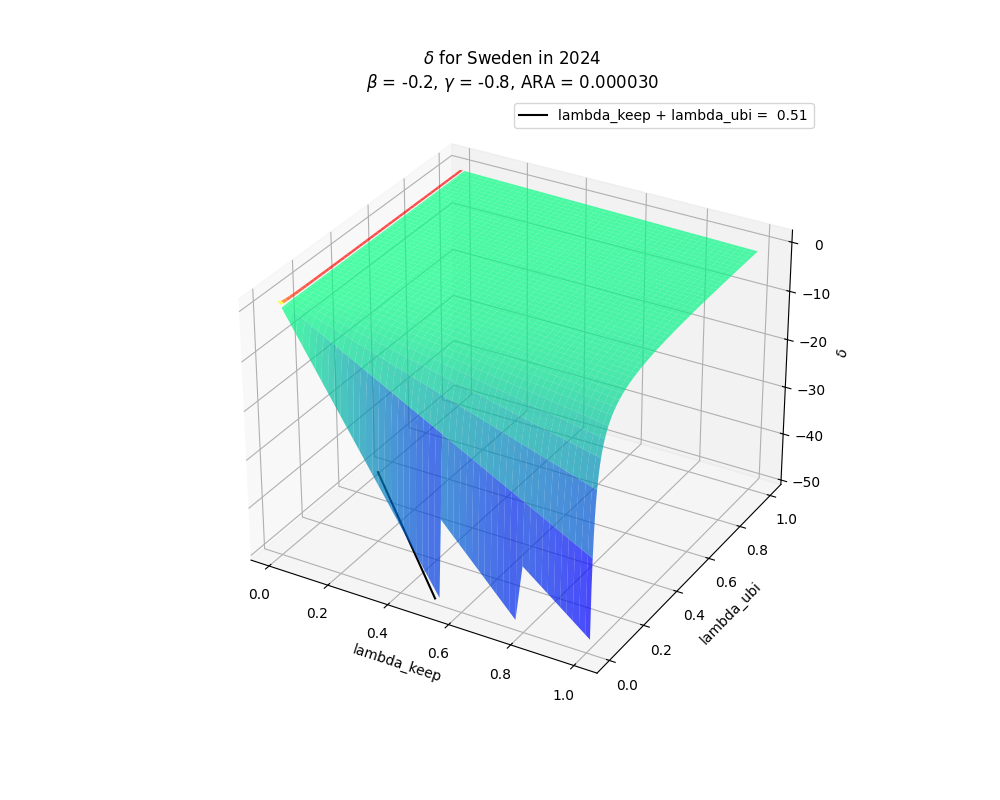

In [124]:
country = 'Sweden'
year = 2024
tax = df.loc[(country, 'Marginal tax wedge of the principal earner'), year] / 100

plot_delta_vary_lambdas(us_swe_df, year, country, beta=-0.2, gamma=-0.8, ara=None, marginal_tax=tax, save_figure=False)

In [125]:
def plot_delta_vary_lambdas_plotly(df, year, country, beta, gamma, ara=None, marginal_tax=None, save_figure=False):
    area_data = df.xs(country, level="Reference area")

    hours = area_data.loc["Hours worked", year]
    consumption = area_data.loc["Consumption per capita", year]
    gross_labour = area_data.loc["Gross labour costs before taxes", year]
    ara = area_data.loc["Absolute risk aversion", year] if ara is None else ara

    lambda_keep_vals = np.linspace(0.01, 1, 200)
    lambda_ubi_vals = np.linspace(0.01, 1, 200)
    lambda_keep, lambda_ubi = np.meshgrid(lambda_keep_vals, lambda_ubi_vals)

    delta_val = delta(
        hours,
        consumption,
        gross_labour,
        beta,
        gamma,
        lambda_keep,
        lambda_ubi,
        ara
    )

    delta_clipped = np.where((delta_val > -50) & (delta_val < 50), delta_val, np.nan)
    
    delta_pos = np.where(delta_clipped > 0, delta_clipped, np.nan)
    delta_neg = np.where(delta_clipped <= 0, delta_clipped, np.nan)

    fig = go.Figure()

    hover_config = (
        'λ_keep: %{x:.2f}<br>' +
        'λ_ubi: %{y:.2f}<br>' +
        'δ: %{z:.4f}<extra></extra>'
    )
    cdata = np.stack((lambda_keep, lambda_ubi), axis=-1)

    fig.add_trace(go.Surface(
        z=delta_pos, x=lambda_keep, y=lambda_ubi,
        colorscale='YlOrRd',
        opacity=0.7,
        showscale=True,
        colorbar=dict(title='δ > 0', x=1.0),
        customdata=cdata,
        hovertemplate=hover_config,
        name='Positive'
    ))

    fig.add_trace(go.Surface(
        z=delta_neg, x=lambda_keep, y=lambda_ubi,
        colorscale='GnBu',
        opacity=0.7,
        showscale=True,
        colorbar=dict(title='δ < 0', x=1.15),
        customdata=cdata,
        hovertemplate=hover_config,
        name='Negative'
    ))

    if marginal_tax is not None:
        # Plot lambda_keep + lambda_ubi = 1 - marginal_tax
        y_line = (1 - marginal_tax) - lambda_keep_vals
        y_line_clipped = np.where((y_line > 0) & (y_line < 1), y_line, np.nan)
        z_line = np.full_like(lambda_keep_vals, np.nanmin(delta_clipped))

        fig.add_trace(
            go.Scatter3d(
                x=lambda_keep_vals,
                y=y_line_clipped,
                z=z_line,
                mode='lines',
                line=dict(color='black', width=4),
                name=f'lambda_keep + lambda_ubi = {1 - marginal_tax: .2f}'
            )
        )

    tick_vals = np.linspace(0, 1, 6)
    tick_text = [f"{v:g}" for v in tick_vals]

    fig.update_layout(
        title=f"δ for {country} in {year}<br><sup>β={beta}, δ={gamma}, RRA={ara:.6f}</sup>",
        scene=dict(
            xaxis=dict(title='λ_keep', tickmode='array', tickvals=tick_vals, ticktext=tick_text, range=[0, 1], autorange=False),
            yaxis=dict(title='λ_ubi', tickmode='array', tickvals=tick_vals, ticktext=tick_text, range=[0, 1], autorange=False),
            zaxis=dict(title='δ', range=[-50, 50]),
            aspectmode='cube'
        ),
        margin=dict(l=0, r=0, b=0, t=80),
        width=1000,
        height=800
    )

    if save_figure:
        prefix = f'vary_lambdas_{country}_{year}_beta={beta}_gamma={gamma}_ara={ara}'
        
        fig_top = go.Figure(fig)
        fig_top.update_layout(
            scene_camera=dict(
                eye=dict(x=0, y=0, z=2),
                projection=dict(type='orthographic')
            )
        )
        fig_iso = go.Figure(fig)
        fig_iso.update_layout(
            scene_camera=dict(
                eye=dict(x=-1.25, y=-1.25, z=1.25),
                projection=dict(type='perspective')
            )
        )

        try:
            fig_top.write_image(f"{prefix}_top_down.png", width=1000, height=800, scale=2)
            fig_iso.write_image(f"{prefix}_isometric.png", width=1000, height=800, scale=2)
        except Exception as e:
            # Fallback: save interactive HTML if static export fails
            print(e)
            fig.write_html(f"{prefix}.html")

    fig.show()

In [ ]:
country = 'Sweden'
year = 2024
tax = df.loc[(country, 'Marginal tax wedge of the principal earner'), year] / 100

plot_delta_vary_lambdas_plotly(us_swe_df, year, country, beta=-0.2, gamma=-0.8, ara=None, marginal_tax=tax, save_figure=False)

In [127]:
def plot_delta_3d_vary_labor(df, year, country, beta, gamma, lambda_keep, lambda_ubi, ara=None, save_figure=False):
    area_data = df.xs(country, level="Reference area")

    hours = area_data.loc["Hours worked", year]
    consumption = area_data.loc["Consumption per capita", year]
    gross_labour = area_data.loc["Gross labour costs before taxes", year]
    ara = area_data.loc["Absolute risk aversion", year] if ara is None else ara

    weekly_labor_hours = np.linspace(1, 100, 100)
    hours_override = weekly_labor_hours * 52

    delta_values = delta(
        hours,
        consumption,
        gross_labour,
        beta,
        gamma,
        lambda_keep,
        lambda_ubi,
        ara,
        hours_override=hours_override
    )

    fig = go.Figure()

    fig.add_trace(
        go.Scatter(
            x=weekly_labor_hours,
            y=delta_values,
            mode='lines',
            line=dict(color='royalblue', width=3),
            name='δ'
        )
    )

    fig.update_layout(
        title=f"δ for {country} in {year}<br><sup>β={beta}, γ={gamma}, λ_keep={lambda_keep}, λ_ubi={lambda_ubi}, ARA={ara:.6f}</sup>",
        xaxis=dict(title='Weekly Hours Worked', range=[weekly_labor_hours.min(), weekly_labor_hours.max()]),
        yaxis=dict(title='δ'),
        template='plotly_white',
        width=900,
        height=600,
        margin=dict(l=40, r=40, t=90, b=40)
    )

    if save_figure:
        prefix = f'vary_labor_{country}_{year}_beta={beta}_gamma={gamma}_keep={lambda_keep}_ubi={lambda_ubi}_ara={ara}'
        fig.write_image(f'prefix.png')

    fig.show()


In [ ]:
country = 'Sweden'
year = 2024

plot_delta_3d_vary_labor(us_swe_df, year, country, beta=-0.2, gamma=-0.8, lambda_keep=0.5, lambda_ubi=0.1, ara=None, save_figure=False)

# When is $\delta$ positive?

In order for $\delta$ to be positive, at the very least, we need 
$$
\begin{align*}
    \frac{\beta}{L} - \frac{\gamma}{1 - L} &> 0 \\
    \frac{\beta}{L} &> \frac{\gamma}{1 - L} \\
    \frac{\beta}{\gamma} &< \frac{L}{1 - L} \quad \text{recall that } \beta < 0 \text{ and } \gamma < 0 \\
    \frac{\gamma}{\beta} &> \frac{1 - L}{L}
\end{align*}
$$
For example, for 1800 hours worked in a year, we have $L \approx 0.3$, so we need
$$
\begin{align*}
    \frac{\gamma}{\beta} &> \frac{1 - L}{L} \approx \frac{0.75}{0.25} = 3
\end{align*}
$$
So we would need to assume that people prefer leisure at least 3 times as much as working.
This seems quite reasonable actually.

Now consider more of the equation for $\delta$:
$$
\begin{align*}
    \delta 
        = \frac{1}{\alpha w \lambda_{ubi}} \left( \frac{\beta}{L} - \frac{\gamma}{1 - L} \right)
        - \frac{\lambda_{keep}}{\lambda_{ubi}} &> 0 
    \\
    \frac{\lambda_{keep}}{\lambda_{ubi}} &< \frac{1}{\alpha w \lambda_{ubi}} \left( \frac{\beta}{L} - \frac{\gamma}{1 - L} \right)
    \\
    \lambda_{keep} &< \frac{1}{\alpha w} \left( \frac{\beta}{L} - \frac{\gamma}{1 - L} \right)
    \\
    \alpha w &< \frac{1}{\lambda_{keep}} \left( \frac{\beta}{L} - \frac{\gamma}{1 - L} \right)
    \\
    \frac{RRA}{c} w &< \frac{1}{\lambda_{keep}} \left( \frac{\beta}{L} - \frac{\gamma}{1 - L} \right)
    \\
    \frac{w}{c} &< \frac{1}{\lambda_{keep} RRA} \left( \frac{\beta}{L} - \frac{\gamma}{1 - L} \right)
    \\
    \frac{\text{earnings} / L}{c} &< \frac{1}{\lambda_{keep} RRA} \left( \frac{\beta}{L} - \frac{\gamma}{1 - L} \right)
    \\
    \frac{\text{earnings}}{c} &< \frac{L}{\lambda_{keep} RRA} \left( \frac{\beta}{L} - \frac{\gamma}{1 - L} \right)
\end{align*}
$$

To justify why reasonable values for $\beta$ and $\gamma$ should have magnitudes less than 1, we can graph the utility function and its derivative to observe the behavior for various values of $\beta$ and $\gamma$.

In [129]:
def utility_plot():
    l_vals = np.linspace(0.01, 0.99, 100)

    def update(beta, gamma):
        u = -(l_vals**beta * (1-l_vals)**gamma)
        du = (l_vals**(beta-1)) * ((1-l_vals)**(gamma-1)) * (l_vals*(beta+gamma) - beta)
        
        fig = go.Figure()
        fig.add_trace(go.Scatter(x=l_vals, y=u, name="U", line=dict(color='firebrick', width=3)))
        fig.add_trace(go.Scatter(x=l_vals, y=du, name="U'", line=dict(color='royalblue', dash='dot')))
        
        fig.update_layout(
            yaxis=dict(range=[-10, 1], zeroline=True, zerolinecolor='black'),
            xaxis=dict(title="labor proportion (L)"),
            title=f"Utility: β={beta:.2f}, γ={gamma:.2f}",
            template="plotly_white",
            margin=dict(l=20, r=20, t=40, b=20),
            height=500  # Vertical height in pixels
        )
        fig.show()

    # Sliders
    slider_layout = Layout(width='80%') 

    beta_slider = FloatSlider(
        min=-5.0, max=-0.01, step=0.01, value=-0.2, 
        description='β:', 
        layout=slider_layout,
        continuous_update=True
    )

    gamma_slider = FloatSlider(
        min=-5.0, max=-0.01, step=0.01, value=-0.8, 
        description='γ:', 
        layout=slider_layout,
        continuous_update=True
    )

    return interact(update, beta=beta_slider, gamma=gamma_slider)

In [130]:
util_plot = utility_plot()
util_plot.widget.layout.width = '50%'

interactive(children=(FloatSlider(value=-0.2, description='β:', layout=Layout(width='80%'), max=-0.01, min=-5.…

# Debug

In [131]:
hours = 1450
consumption = 45_000
gross_labour_costs = 80_000
beta = -0.5
gamma = -5
lambda_keep = 0.3
lambda_ubi = 0.3
rra = 1.53

delta(hours, consumption, gross_labour_costs, beta, gamma, lambda_keep, lambda_ubi, rra)

-0.9999686415948308

In [132]:
labor_proportion(1450)

0.2482876712328767

In [ ]:
alpha = [alpha_p, alpha_m, alpha_r] 
gross_labour = [wage_p, wage_m, wage_r]
hours = [hours_p, hours_m, hours_r]

def delta_system(hours, consumption, gross_labour, beta, gamma, lambda_keep, lambda_ubi, rra, daily_sleep_hours=8.0, hours_override=None):
    empirical_L = labor_proportion(hours, daily_sleep_hours)
    w = gross_labour / empirical_L

    L = empirical_L if hours_override is None else labor_proportion(hours_override, daily_sleep_hours)

    alpha = rra / consumption

    term1 = (1 / (alpha * w * lambda_ubi)) * (beta / L - gamma / (1 - L))
    return term1 - lambda_keep / lambda_ubi


In [134]:
# ! pip install scipy
from scipy.optimize import fsolve

def ubi_equilibrium(vars, I, weights, wages, alpha, beta, gamma, l_keep, l_ubi, L_target):
    # vars: [Lr, La, Lp, delta]
    Lr, La, Lp, delta = vars
    
    # Utility function part
    def mu_leisure(L):
        return (beta / L) - (gamma / (1 - L))
    
    # The common tax/UBI multiplier
    multiplier = l_keep + (l_ubi / I) * (1 + delta * (I - 1))
    
    # Equations for each bracket
    eq_rich = alpha * wages[0] * multiplier - mu_leisure(Lr)
    eq_avg  = alpha * wages[1] * multiplier - mu_leisure(La)
    eq_poor = alpha * wages[2] * multiplier - mu_leisure(Lp)
    
    # Population-weighted labor constraint
    # (Sum of weight * labor supply must equal the total economic labor target)
    eq_total_labor = (weights[0]*Lr + weights[1]*La + weights[2]*Lp) - L_target
    
    return [eq_rich, eq_avg, eq_poor, eq_total_labor]

# Settings
I = 1000
weights = [0.10, 0.70, 0.20]  # 10% Rich, 70% Avg, 20% Poor
wages = [150, 50, 20]        # Wage gap
L_target = 0.4               # We want the average person to work 40% of their time

# Lambda keep, lambda ubi change with each tax bracket
# Solve
initial_guesses = [0.3, 0.4, 0.5, 0.5] # [Lr, La, Lp, delta]
sol = fsolve(ubi_equilibrium, initial_guesses, args=(I, weights, wages, 0.5, 0.2, 0.8, 0.7, 0.1, L_target))

print(f"Calculated Delta: {sol[3]:.4f}")
print(f"Labor Supply -> Rich: {sol[0]:.2f}, Avg: {sol[1]:.2f}, Poor: {sol[2]:.2f}")

Calculated Delta: -7.3349
Labor Supply -> Rich: 0.71, Avg: 0.40, Poor: 0.26
